In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

# Run from C&G_Threshold_Change folder, or set path explicitly
base_path = Path(".").resolve()

# ── Shared style settings ──
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.color": "#cccccc",
    "grid.linestyle": "--",
    "grid.alpha": 0.6,
    "font.family": "serif",
    "font.size": 12,
})

CPLEX_COLOR = "#E8860C"   # orange
GA_COLOR    = "#228B22"   # forest green


def plot_bar_from_csv(csv_name: str, y_label: str):
    """Publication-quality grouped bar chart (Optimum vs MT2TE)."""
    df = pd.read_csv(base_path / csv_name)
    thresholds = df["threshold"].astype(str)
    cplex_vals = pd.to_numeric(df["CPLEX"], errors="coerce").values
    ga_vals    = pd.to_numeric(df["GA"], errors="coerce").values

    x = np.arange(len(thresholds))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))

    bars1 = ax.bar(
        x - width / 2, cplex_vals, width,
        label="Optimum", color=CPLEX_COLOR,
        edgecolor="black", linewidth=0.8,
        hatch="...",
    )
    bars2 = ax.bar(
        x + width / 2, ga_vals, width,
        label="MT2TE", color=GA_COLOR,
        edgecolor="black", linewidth=0.8,
        hatch="///",
    )

    # Y range for label offset and axis limits
    ymin = np.nanmin(np.concatenate([cplex_vals, ga_vals]))
    ymax = np.nanmax(np.concatenate([cplex_vals, ga_vals]))
    y_range = ymax - ymin if ymax > ymin else 1
    label_offset = max(y_range * 0.02, 0.005)  # small fraction of range, so labels sit just above bars
    margin = y_range * 0.15

    # Value labels on top of each bar
    for bar_group in (bars1, bars2):
        for bar in bar_group:
            h = bar.get_height()
            if not np.isnan(h):
                ax.text(
                    bar.get_x() + bar.get_width() / 2, h + label_offset,
                    f"{h:g}", ha="center", va="bottom",
                    fontsize=10, fontweight="bold",
                )

    ax.set_xlabel("Threshold", fontsize=13, fontweight="bold")
    ax.set_ylabel(y_label, fontsize=13, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(thresholds, fontsize=12)
    ax.legend(title="Algorithm", fontsize=11, title_fontsize=11,
              frameon=True, fancybox=True, shadow=True)
    ax.set_axisbelow(True)

    ax.set_ylim(bottom=max(0, ymin - margin * 2), top=ymax + margin)

    plt.tight_layout()
    plt.show()


def plot_runtime_line(csv_name: str = "runtime.csv"):
    """Line chart for runtime comparison (Optimum vs MT2TE)."""
    df = pd.read_csv(base_path / csv_name)
    thresholds = df["threshold"].values
    cplex_vals = pd.to_numeric(df["CPLEX"], errors="coerce").values
    ga_vals    = pd.to_numeric(df["GA"], errors="coerce").values

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.plot(
        thresholds, cplex_vals,
        color="#7B2D8E", marker="o", markersize=8,
        linestyle="--", linewidth=2,
        label="Optimum",
    )
    ax.plot(
        thresholds, ga_vals,
        color=GA_COLOR, marker="v", markersize=8,
        linestyle="-", linewidth=2,
        label="MT2TE",
    )

    ax.set_xlabel("Threshold", fontsize=13, fontweight="bold")
    ax.set_ylabel("Execution Time (sec)", fontsize=13, fontweight="bold")
    ax.set_xticks(thresholds)
    ax.legend(title="Algorithm", fontsize=11, title_fontsize=11,
              frameon=True, fancybox=True, shadow=True)
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.show()

## Runtime

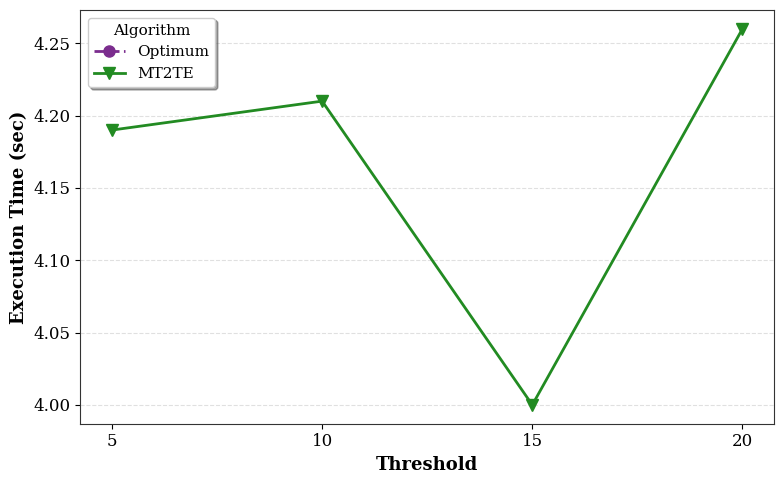

In [2]:
plot_runtime_line("runtime.csv")

## Distance

C:\Users\ranji\AppData\Local\Temp\ipykernel_11208\2904181945.py:78: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


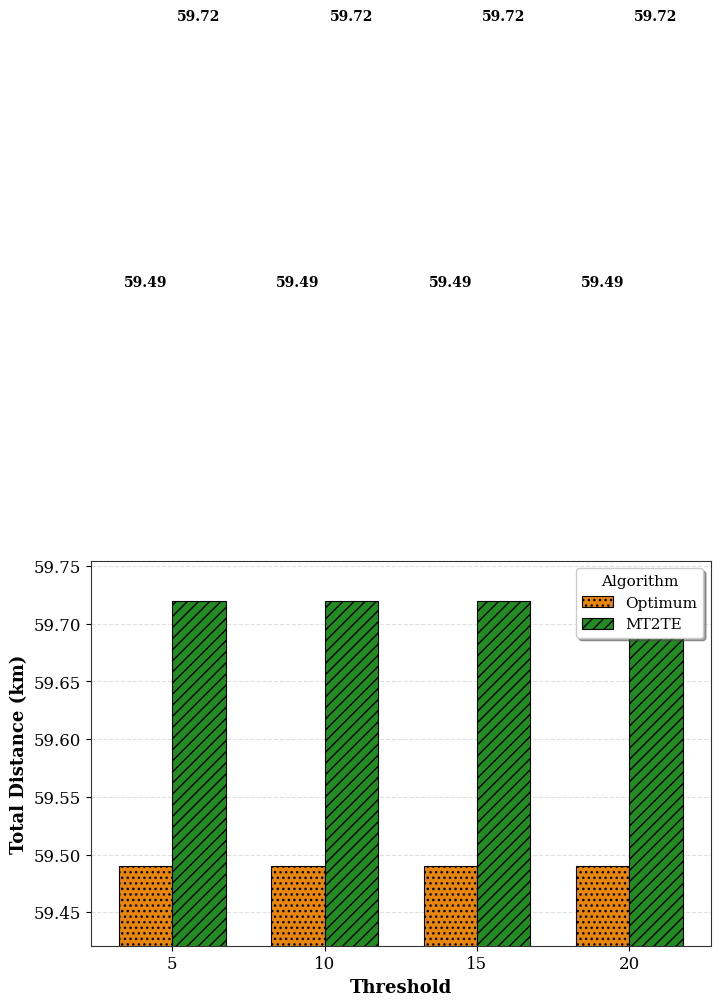

In [3]:
plot_bar_from_csv("distance.csv", "Total Distance (km)")

## Travel Time

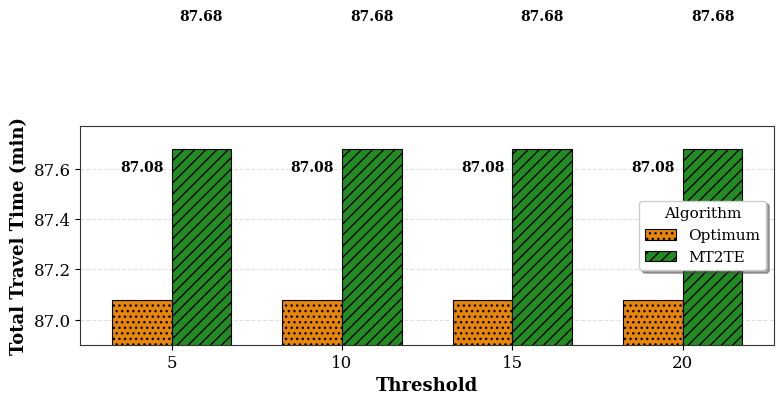

In [4]:
plot_bar_from_csv("travelTime.csv", "Total Travel Time (min)")

## Energy Consumption

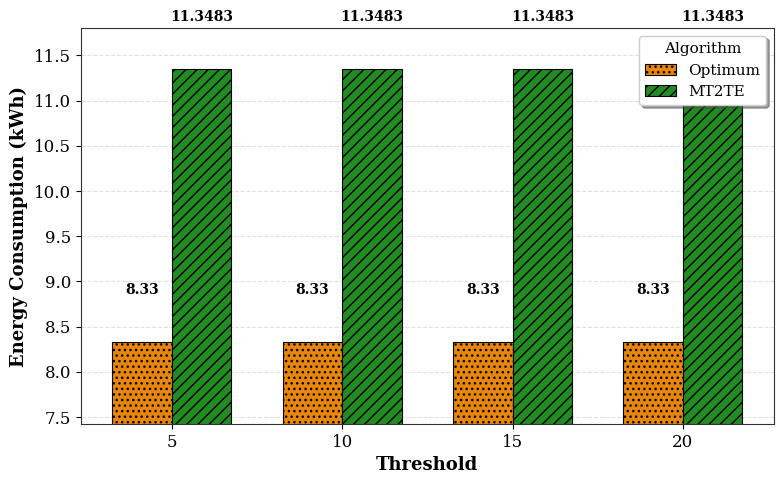

In [5]:
plot_bar_from_csv("energy_consumption.csv", "Energy Consumption (kWh)")

## Energy Charge (CS and ERS)

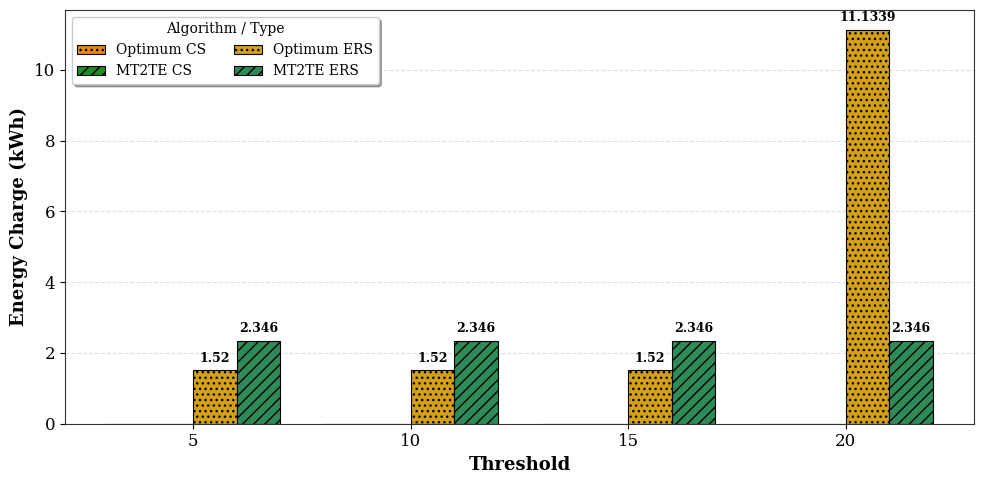

In [6]:
df_cs  = pd.read_csv(base_path / "energy_charge_CS.csv")
df_ers = pd.read_csv(base_path / "energy_charge_ERS.csv")

thresholds = df_cs["threshold"].astype(str).values
x = np.arange(len(thresholds))
width = 0.2

vals = {
    "Optimum CS":  df_cs["CPLEX"].values,
    "MT2TE CS":    df_cs["GA"].values,
    "Optimum ERS": df_ers["CPLEX"].values,
    "MT2TE ERS":   df_ers["GA"].values,
}

colors   = [CPLEX_COLOR, GA_COLOR, "#D4A017", "#2E8B57"]
hatches  = ["...", "///", "...", "///"]
offsets  = [-1.5, -0.5, 0.5, 1.5]

fig, ax = plt.subplots(figsize=(10, 5))

for (label, v), color, hatch, off in zip(vals.items(), colors, hatches, offsets):
    bars = ax.bar(
        x + off * width, v, width,
        label=label, color=color,
        edgecolor="black", linewidth=0.8, hatch=hatch,
    )
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2, h + 0.15,
                f"{h:g}", ha="center", va="bottom",
                fontsize=9, fontweight="bold",
            )

ax.set_xlabel("Threshold", fontsize=13, fontweight="bold")
ax.set_ylabel("Energy Charge (kWh)", fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(thresholds, fontsize=12)
ax.legend(title="Algorithm / Type", fontsize=10, title_fontsize=10,
          frameon=True, fancybox=True, shadow=True, ncol=2)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()